NAME :- LALIT PATHADE

ROLL NO :-58

PRN :-12411458

DIV :- CSAI-D

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

LOAD DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('Iris.csv')

# Show first 5 rows
df.head()

Saving Iris.csv to Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


DATA PREPROCESSING

In [ ]:
# Drop unnecessary column
df = df.drop('Id', axis=1)

# Separate features
X = df.drop('Species', axis=1)

# Feature scaling (IMPORTANT for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ELBOW METHOD

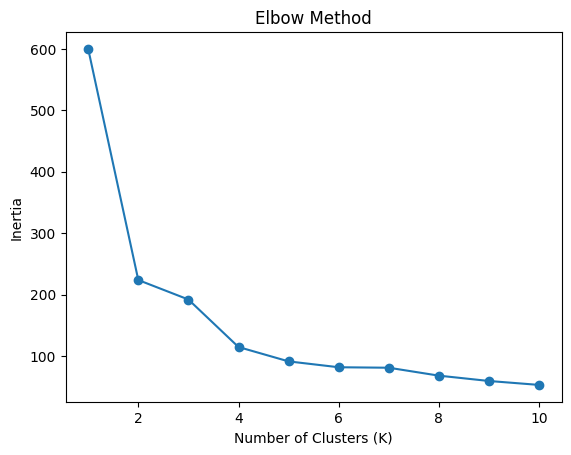

In [ ]:
inertia_values = []

# Try K from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot elbow graph
plt.figure()
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

APPLY K MEANS

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_kmeans

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,2
2,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5.0,3.6,1.4,0.2,Iris-setosa,1


VISUALIZE CLUSTERS

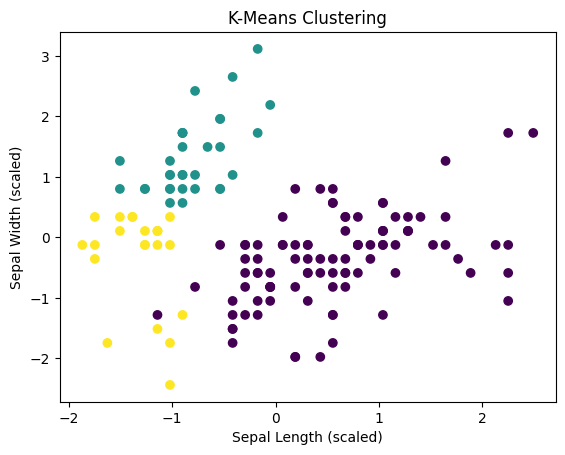

In [ ]:
plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.title('K-Means Clustering')

plt.show()